## **Setup**

In [1]:
import os, sys

# Repository information
REPO_NAME = "RecSys-Challenge-2025"
REPO_URL  = f"github.com/Lv1g1/{REPO_NAME}.git"

# Detect environment
IS_COLAB = 'content' in os.getcwd()
IS_KAGGLE = 'kaggle' in os.getcwd()
IS_LOCAL = not (IS_COLAB or IS_KAGGLE)

WORKING_DIR = os.getcwd()

if IS_COLAB:
    WORKING_DIR = "/content"

    # Mount Google Drive
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)

    # Get GitHub token via input
    def get_token():
        from getpass import getpass
        return getpass("GitHub Token: ")

elif IS_KAGGLE:
    WORKING_DIR = "/kaggle/working"

    # Get GitHub token from Kaggle secrets
    def get_token():
        from kaggle_secrets import UserSecretsClient
        return UserSecretsClient().get_secret("Token")

# If local environment assume inside the repo
LOCAL_REPO_PATH = "/home/luigi/RecSys" if IS_LOCAL else os.path.join(WORKING_DIR, REPO_NAME)

# Clone the repository if it doesn't exist
if not os.path.exists(LOCAL_REPO_PATH):
    os.chdir(WORKING_DIR)
    token = get_token()

    !git clone https://{token}@{REPO_URL}
else:
    print("Repo already exists — pulling latest changes")
    os.chdir(LOCAL_REPO_PATH)
    !git pull
    os.chdir(WORKING_DIR)

# Add to Python PATH
if LOCAL_REPO_PATH not in sys.path:
    sys.path.append(LOCAL_REPO_PATH)

if IS_COLAB:
    !pip install optuna

Repo already exists — pulling latest changes
fatal: unable to access 'https://github.com/Lv1g1/RecSys-Challenge-2025.git/': Could not resolve host: github.com


In [2]:
if IS_COLAB or False:  # Set to True if you want to recompile Cython files
    os.chdir(LOCAL_REPO_PATH)
    !python run_compile_all_cython.py
    os.chdir(WORKING_DIR)

## **Imports**

In [3]:
import os, gc
import joblib
import pandas as pd
import numpy as np
from xgboost import XGBRanker, plot_importance

from Challenge.paths import XGBOOST_DATAFRAMES, XGBOOST_MODELS, generate_submission
from Challenge.XGBoostReranker import XGBoostRerankerRecommender, ProgressCallback

Running on local — storage at: /home/luigi/RecSys


## **Load Data**

In [4]:
feature_cols = ['top_10', 'top_20', 'top_30', 'top_40', 'top_50', 'EASE_R_Score',
       'EASE_R_RankPosition', 'SLIMElasticNet_Score',
       'SLIMElasticNet_RankPosition', 'MultVAE_Score', 'MultVAE_RankPosition',
       'MatrixFactorization_WARP_Score',
       'MatrixFactorization_WARP_RankPosition', 'IALS_Score',
       'IALS_RankPosition', 'RP3beta_Score', 'RP3beta_RankPosition',
       'P3alpha_Score', 'P3alpha_RankPosition', 'UserKNN_cosine_Score',
       'UserKNN_cosine_RankPosition', 'UserKNN_tversky_Score',
       'UserKNN_tversky_RankPosition', 'ItemKNN_cosine_Score',
       'ItemKNN_cosine_RankPosition', 'ItemKNN_tversky_Score',
       'ItemKNN_tversky_RankPosition', 'SLIMElasticNet_MaxSim',
       'SLIMElasticNet_MeanSim', 'SLIMElasticNet_StdSim',
       'SLIMElasticNet_MatchCount', 'RP3beta_MaxSim', 'RP3beta_MeanSim',
       'RP3beta_StdSim', 'RP3beta_MatchCount', 'User_Cluster', 'Item_Cluster',
       'Cluster_Interaction', 'User_Cluster_Dist', 'Item_Cluster_Dist',
       'User_to_ItemCluster_Dist', 'Mean_RankPosition', 'Std_RankPosition',
       'Min_RankPosition', 'Mean_Score', 'Std_Score', 'Max_Score',
       'User_Profile_Len', 'Item_Global_Popularity',
       'User_Avg_Item_Popularity']

In [5]:
# Concatenate all folds
all_dfs = []
for fold_idx in range(10):
    file_path = os.path.join(XGBOOST_DATAFRAMES, "OOF_folds", f"prediction_train_OOF_fold{fold_idx}.parquet")

    df_fold = pd.read_parquet(
        file_path,
        engine='fastparquet',
        columns=['UserID', 'ItemID', 'Label'] + feature_cols
    )

    print(f"Loaded successfully from: {file_path}")
    all_dfs.append(df_fold)

X_train_full = pd.concat(all_dfs, ignore_index=True)

# Free memory
del all_dfs
gc.collect()

# Sort by UserID for faster access during training
X_train_full.sort_values(by='UserID', inplace=True)

# Categorical handling
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    if col in X_train_full.columns:
        X_train_full[col] = X_train_full[col].astype('category')

print(f"Final OOF Dataset Shape: {X_train_full.shape}")
print(f"Memory Usage: {X_train_full.memory_usage().sum() / 1e6:.2f} MB")

assert X_train_full['UserID'].is_monotonic_increasing, "Training set is not sorted by UserID!"

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold0.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold1.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold2.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold3.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold4.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold5.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold6.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/prediction_train_OOF_fold7.parquet
Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/OOF_folds/

In [6]:
X_train_full.columns

Index(['UserID', 'ItemID', 'Label', 'top_10', 'top_20', 'top_30', 'top_40',
       'top_50', 'EASE_R_Score', 'EASE_R_RankPosition', 'SLIMElasticNet_Score',
       'SLIMElasticNet_RankPosition', 'MultVAE_Score', 'MultVAE_RankPosition',
       'MatrixFactorization_WARP_Score',
       'MatrixFactorization_WARP_RankPosition', 'IALS_Score',
       'IALS_RankPosition', 'RP3beta_Score', 'RP3beta_RankPosition',
       'P3alpha_Score', 'P3alpha_RankPosition', 'UserKNN_cosine_Score',
       'UserKNN_cosine_RankPosition', 'UserKNN_tversky_Score',
       'UserKNN_tversky_RankPosition', 'ItemKNN_cosine_Score',
       'ItemKNN_cosine_RankPosition', 'ItemKNN_tversky_Score',
       'ItemKNN_tversky_RankPosition', 'SLIMElasticNet_MaxSim',
       'SLIMElasticNet_MeanSim', 'SLIMElasticNet_StdSim',
       'SLIMElasticNet_MatchCount', 'RP3beta_MaxSim', 'RP3beta_MeanSim',
       'RP3beta_StdSim', 'RP3beta_MatchCount', 'User_Cluster', 'Item_Cluster',
       'Cluster_Interaction', 'User_Cluster_Dist', 'Item_C

## **Train**

In [ ]:
params = {
    'n_estimators': 3000,
    'objective': 'rank:ndcg',
    'grow_policy': 'depthwise',
    
    'learning_rate': 0.01069123309545738,
    'min_child_weight': 87,
    'max_depth': 12,
    'subsample': 0.9223569068695108,
    'colsample_bytree': 0.8324436314210852,
    'reg_alpha': 0.5066160208194748,
    'reg_lambda': 1.474781469320333
}

N_FOLDS = 10
for fold_idx in range(N_FOLDS):
    print(f"\n=== Training fold {fold_idx} ===")

    print(f"Preparing training and validation sets for fold {fold_idx}...")
    # Prepare training and validation sets
    X_train = X_train_full[X_train_full['UserID'] % N_FOLDS != fold_idx]
    X_val = X_train_full[X_train_full['UserID'] % N_FOLDS == fold_idx]

    # Groups
    groups = X_train.groupby("UserID").size().values
    val_groups = X_val.groupby("UserID").size().values

    # Target
    y_train = X_train["Label"]
    y_val = X_val["Label"]

    # Drop metadata to create Feature Matrix
    # X_train = X_train.drop(columns=["Label", "UserID", "ItemID"], errors='ignore')
    X_train = X_train[feature_cols]
    X_val = X_val[feature_cols]

    assert groups.sum() == X_train.shape[0], "Group sum mismatch!"
    assert val_groups.sum() == X_val.shape[0], "Group sum mismatch!"

    print("Starting training...")
    XGB_model = XGBRanker(
        **params,
        enable_categorical=True,
        tree_method="hist",
        n_jobs=-1,
        random_state=42,
        callbacks=[
            ProgressCallback(total_trees=params['n_estimators'], period=50)
        ],
        eval_metric=["map@20"],
        early_stopping_rounds=150
    )

    XGB_model.fit(
        X_train, y_train, group=groups,
        eval_set=[(X_val, y_val)],
        eval_group=[val_groups],
        verbose=False
    )

    print(f"Training ended at tree {XGB_model.best_iteration}")
    print(f"Best Score: {XGB_model.best_score}")

    # Store model
    model_save_path = os.path.join(XGBOOST_MODELS, f"xgboost_model_fold{fold_idx}.joblib")
    joblib.dump(XGB_model, model_save_path)
    print(f"Model for fold {fold_idx} saved to {model_save_path}")


=== Training fold 0 ===
Preparing training and validation sets for fold 0...
Starting training...
[Training] Tree 50/3000 | [validation_0] map@20: 0.13295
[Training] Tree 100/3000 | [validation_0] map@20: 0.13494
[Training] Tree 150/3000 | [validation_0] map@20: 0.13683
[Training] Tree 200/3000 | [validation_0] map@20: 0.13807
[Training] Tree 250/3000 | [validation_0] map@20: 0.13847
[Training] Tree 300/3000 | [validation_0] map@20: 0.13914
[Training] Tree 350/3000 | [validation_0] map@20: 0.13968
[Training] Tree 400/3000 | [validation_0] map@20: 0.14007
[Training] Tree 450/3000 | [validation_0] map@20: 0.14089
[Training] Tree 500/3000 | [validation_0] map@20: 0.14147
[Training] Tree 550/3000 | [validation_0] map@20: 0.14160
[Training] Tree 600/3000 | [validation_0] map@20: 0.14182
[Training] Tree 650/3000 | [validation_0] map@20: 0.14235
[Training] Tree 700/3000 | [validation_0] map@20: 0.14244
[Training] Tree 750/3000 | [validation_0] map@20: 0.14258
[Training] Tree 800/3000 | [vali

KeyboardInterrupt: 

In [7]:
params = {
    'n_estimators': 800,
    'objective': 'rank:ndcg',
    'grow_policy': 'depthwise',
    
    'learning_rate': 0.01069123309545738,
    'min_child_weight': 87,
    'max_depth': 12,
    'subsample': 0.9223569068695108,
    'colsample_bytree': 0.8324436314210852,
    'reg_alpha': 0.5066160208194748,
    'reg_lambda': 1.474781469320333
}

# Prepare training and validation sets
X_train = X_train_full

# Groups
groups = X_train.groupby("UserID").size().values

# Target
y_train = X_train["Label"]

# Drop metadata to create Feature Matrix
# X_train = X_train.drop(columns=["Label", "UserID", "ItemID"], errors='ignore')
X_train = X_train[feature_cols]

assert groups.sum() == X_train.shape[0], "Group sum mismatch!"

for s in [0xbeef, 0xbabe, 0xc0ffe, 0xface, 42]:
    print(f"\n=== Training seed: {s} ===")
    
    if s == 0xbabe or s == 0xface:
        params['n_estimators'] = 850
    else:
        params['n_estimators'] = 800

    XGB_model = XGBRanker(
        **params,
        enable_categorical=True,
        tree_method="hist",
        n_jobs=-1,
        random_state=s,
        callbacks=[
            ProgressCallback(total_trees=params['n_estimators'], period=50)
        ]
    )

    XGB_model.fit(
        X_train, y_train, group=groups,
        verbose=False
    )

    # Store model
    model_save_path = os.path.join(XGBOOST_MODELS, f"xgboost_model_seed_{s}.joblib")
    joblib.dump(XGB_model, model_save_path)
    print(f"Model for seed {s} saved to {model_save_path}")


=== Training seed: 48879 ===
[Training] Tree 50/800
[Training] Tree 100/800
[Training] Tree 150/800
[Training] Tree 200/800
[Training] Tree 250/800
[Training] Tree 300/800
[Training] Tree 350/800
[Training] Tree 400/800
[Training] Tree 450/800
[Training] Tree 500/800
[Training] Tree 550/800
[Training] Tree 600/800
[Training] Tree 650/800
[Training] Tree 700/800
[Training] Tree 750/800
[Training] Tree 800/800
Model for seed 48879 saved to /home/luigi/RecSys/xg_boost_data/models/xgboost_model_seed_48879.joblib

=== Training seed: 47806 ===
[Training] Tree 50/850
[Training] Tree 100/850
[Training] Tree 150/850
[Training] Tree 200/850
[Training] Tree 250/850
[Training] Tree 300/850
[Training] Tree 350/850
[Training] Tree 400/850
[Training] Tree 450/850
[Training] Tree 500/850
[Training] Tree 550/850
[Training] Tree 600/850
[Training] Tree 650/850
[Training] Tree 700/850
[Training] Tree 750/850
[Training] Tree 800/850
[Training] Tree 850/850
Model for seed 47806 saved to /home/luigi/RecSys

## **Generate submission**

In [6]:
file_path = os.path.join(XGBOOST_DATAFRAMES, "prediction_OOF.parquet")

X_pred = pd.read_parquet(
    file_path,
    engine='fastparquet',
    columns=['UserID', 'ItemID'] + feature_cols
)

print(f"Loaded successfully from: {file_path}")

# Reorder val columns to match training set
X_pred = X_pred[feature_cols + ['UserID', 'ItemID']]

# Make categorical features if any
for col in ['User_Cluster', 'Item_Cluster', 'Cluster_Interaction']:
    X_pred[col] = X_pred[col].astype('category')

assert X_pred['UserID'].is_monotonic_increasing, "Validation set is not sorted by UserID!"

X_pred

Loaded successfully from: /home/luigi/RecSys/xg_boost_data/dataframes/prediction_OOF.parquet


,top_10,top_20,top_30,top_40,top_50,EASE_R_Score,EASE_R_RankPosition,SLIMElasticNet_Score,SLIMElasticNet_RankPosition,MultVAE_Score,...,Std_RankPosition,Min_RankPosition,Mean_Score,Std_Score,Max_Score,User_Profile_Len,Item_Global_Popularity,User_Avg_Item_Popularity,UserID,ItemID
0,0,0,0,0,0,0.132006,99,0.172805,59,0.052053,...,672,59,0.089565,0.088469,0.355987,96,539,2114.25000,0,13
1,0,0,0,0,0,0.204096,32,0.183844,53,0.313910,...,173,15,0.187918,0.166697,0.775875,96,947,2114.25000,0,76
2,0,0,0,0,1,0.220318,23,0.146191,82,0.440643,...,216,23,0.180377,0.135085,0.553303,96,4209,2114.25000,0,86
3,0,0,0,1,1,0.182187,49,0.237055,29,0.495977,...,510,18,0.211107,0.138392,0.495977,96,222,2114.25000,0,333
4,0,0,0,0,1,0.137585,93,0.133833,103,0.461025,...,912,11,0.184062,0.151802,0.523792,96,3345,2114.25000,0,412
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2284684,0,0,0,1,1,0.162291,186,0.091869,363,0.589345,...,1298,13,0.193600,0.207011,0.701868,314,166,1140.53186,27094,6572
2284685,0,0,0,0,0,0.260803,65,0.320783,55,0.261967,...,323,55,0.227020,0.171106,0.498404,314,497,1140.53186,27094,6620
2284686,0,0,0,0,0,0.245474,74,0.299292,64,0.325116,...,157,38,0.288896,0.184655,0.548562,314,1300,1140.53186,27094,6626
2284687,0,0,0,0,0,0.231821,82,0.205437,131,0.564016,...,445,3,0.277302,0.269766,0.788353,314,277,1140.53186,27094,6724


In [7]:
class VotingXGBRanker:
    def __init__(self, models):
        self.models = models
        
    def predict(self, X, *args, **kwargs):
        # Predict with ALL models
        predictions = [m.predict(X) for m in self.models]
        # Average the predictions (Soft Voting)
        avg_prediction = np.mean(predictions, axis=0)
        return avg_prediction

In [10]:
XGBoost_models = []
for s in [0xbeef, 0xbabe, 0xc0ffe, 0xface, 42]:
    model_load_path = os.path.join(XGBOOST_MODELS, f"xgboost_model_seed_{s}.joblib")
    XGB_model = joblib.load(model_load_path)
    print(f"Model for seed {s} loaded from {model_load_path}")
    XGBoost_models.append(XGB_model)

ensemble_model = VotingXGBRanker(XGBoost_models)

Model for seed 48879 loaded from /home/luigi/RecSys/xg_boost_data/models/xgboost_model_seed_48879.joblib
Model for seed 47806 loaded from /home/luigi/RecSys/xg_boost_data/models/xgboost_model_seed_47806.joblib
Model for seed 790526 loaded from /home/luigi/RecSys/xg_boost_data/models/xgboost_model_seed_790526.joblib
Model for seed 64206 loaded from /home/luigi/RecSys/xg_boost_data/models/xgboost_model_seed_64206.joblib
Model for seed 42 loaded from /home/luigi/RecSys/xg_boost_data/models/xgboost_model_seed_42.joblib


In [14]:
recommender = XGBoostRerankerRecommender(ensemble_model, X_pred)

In [ ]:
generate_submission(recommender, "xg_boost_oof_less_cols.csv")

## **Plot**

<Axes: title={'center': 'Weight (Frequency)'}, xlabel='Importance score', ylabel='Features'>

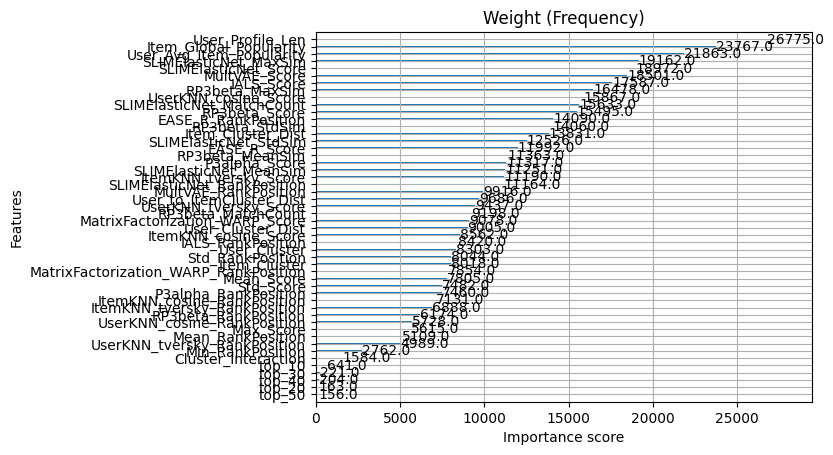

In [11]:
plot_importance(XGBoost_models[0], importance_type='weight', title='Weight (Frequency)')

<Axes: title={'center': 'Gain'}, xlabel='Importance score', ylabel='Features'>

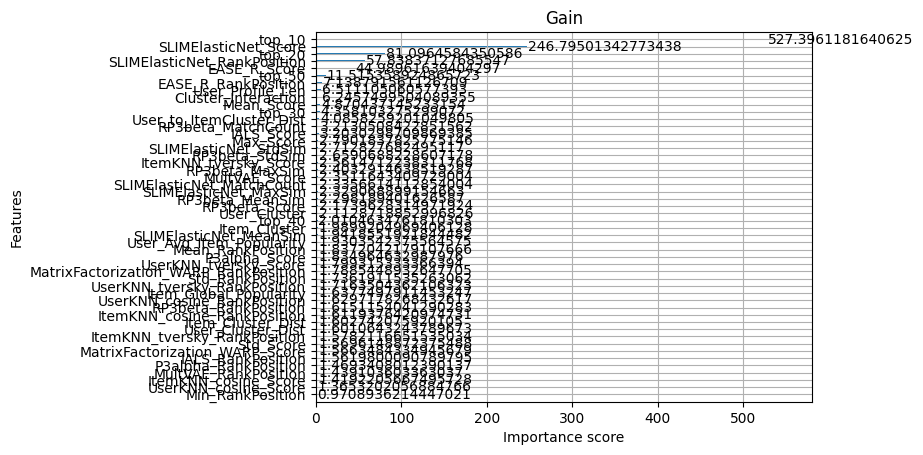

In [12]:
plot_importance(XGBoost_models[0], importance_type='gain', title='Gain')

<Axes: title={'center': 'Cover'}, xlabel='Importance score', ylabel='Features'>

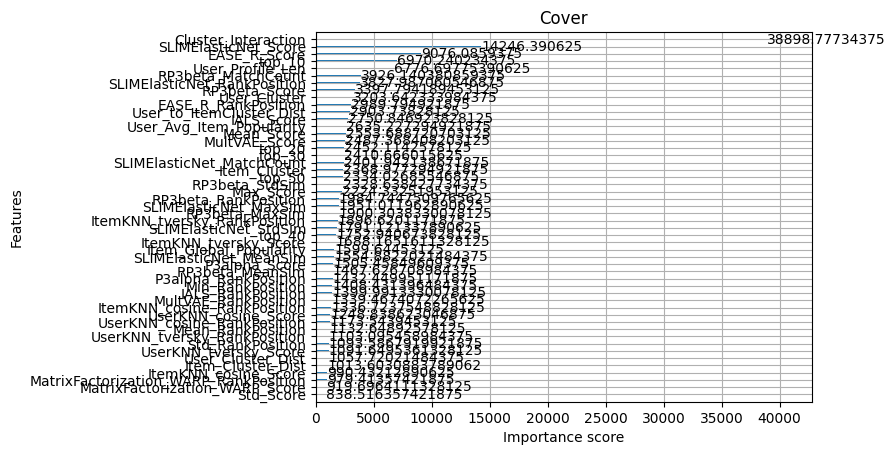

In [13]:
plot_importance(XGBoost_models[0], importance_type='cover', title='Cover')